In [1]:
import shutil
import os

if os.path.exists('/content/drylands_project'):
    shutil.rmtree('/content/drylands_project')
    print("Removed existing 'drylands_project' directory.")
else:
    print("'drylands_project' directory does not exist, nothing to remove.")

Removed existing 'drylands_project' directory.


In [2]:
!git clone https://github.com/zvireek/drylands_project.git

Cloning into 'drylands_project'...
remote: Enumerating objects: 106, done.
remote: Counting objects: 100% (106/106), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 106 (delta 26), reused 91 (delta 15), pack-reused 0 (from 0)
Receiving objects: 100% (106/106), 22.85 KiB | 7.62 MiB/s, done.
Resolving deltas: 100% (26/26), done.


In [4]:
import sys

project_path = '/content/drylands_project'

sys.path.insert(0, project_path)

import numpy as np
import tqdm.auto as tqdm
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

plt.rcParams["animation.html"] = "jshtml"

from pipeline.model import KlausmeierModel
from pipeline.solver import ImplicitSolver

In [10]:
def bifurcation_diagram(a_start = 0, a_end = 1.5):
    a_vals = np.linspace(a_end, a_start, 100, endpoint=False)
    dt = 0.1
    imp_solver = ImplicitSolver()
    klaus_model = KlausmeierModel(dx=0.5, L=50, a=a_end, m=0.45, d1=1, d2=0.05)

    maxes = []
    avs = []
    vs = []

    for aa in tqdm(a_vals):
        u_end, v_end = klaus_model.run_simulation(dt, 1500, imp_solver, tolerance = 0.00001, verbose=False)
        maxes.append(np.max(v_end))
        avs.append(np.average(v_end))
        vs.append(v_end)
        klaus_model.set_a(aa)

    return a_vals, maxes, avs, vs

x_vals, m, a, vs = bifurcation_diagram()

  0%|          | 0/100 [00:00<?, ?it/s]

Model initial conditions set to: something
Solver parameters set up with LU decomposition.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergence reached in solver.
Convergenc

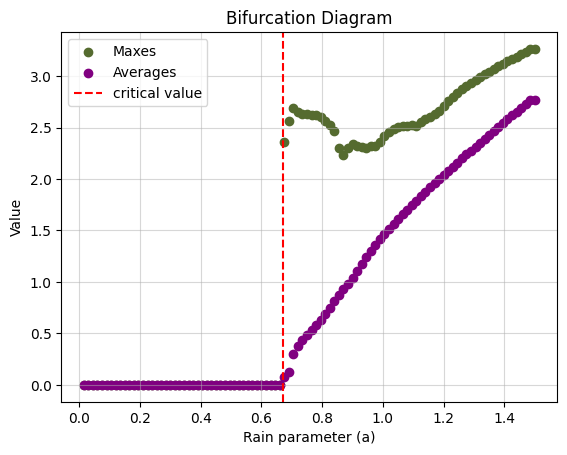

In [19]:
plt.scatter(x_vals, m, label='Maxes', c="darkolivegreen")
plt.scatter(x_vals, a, label='Averages', c="purple")

# Add vertical line at 0.65 and label it "Threshold"
plt.axvline(x=0.67, color='red', linestyle='--', label='critical value')

plt.xlabel('Rain parameter (a)')
plt.ylabel('Value')
plt.grid(True, alpha=0.5)
plt.title('Bifurcation Diagram')
plt.legend()
plt.show()

In [21]:
N = 101

vs_square = [vs[i].reshape(N, N) for i in range(len(vs))]
max_value = np.max(vs_square)

nt, nx, ny = len(vs_square), N, N

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(vs_square[0], vmin=0, vmax=max_value, cmap='viridis', animated=True, interpolation='nearest')
plt.colorbar(im)
ax.set_title("Frame: 0")

def update(frame):
    im.set_array(vs_square[frame])
    ax.set_title(f"Frame: {frame}")
    return [im]

ani = FuncAnimation(fig, update, frames=nt, interval=250, blit=True)

plt.close()
ani

In [ ]:
from matplotlib.animation import FFMpegWriter

writer = FFMpegWriter(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('klausmeier_animation.mp4', writer=writer)